# Análisis de Telemetría y Uso de Tokens LLM (Configured LLM)
Este notebook carga y analiza el uso de tokens, costes y llamadas realizadas a los modelos LLM, desglosado por componentes y pasos del pipeline.

In [8]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- TU CÓDIGO DE INICIALIZACIÓN ---
repo_root = Path.cwd()
if not (repo_root / "models").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.intermediate_io import TEST_LLM_TOKEN_USAGE_FILE

## 1. Carga y Preparación de los Datos JSON
Vamos a cargar el contenido del JSON de telemetría y a convertir la lista de llamadas (`calls`) en un DataFrame de Pandas para facilitar su análisis y visualización.

In [18]:
# Como tienes la ruta en TEST_LLM_TOKEN_USAGE_FIL, construimos el path
json_path = repo_root / "intermediate_outputs" / TEST_LLM_TOKEN_USAGE_FILE

# Leemos el archivo JSON directamente
with open(json_path, "r") as f:
    telemetry_data = json.load(f)

# Extraemos las métricas globales
print("--- MÉTRICAS GLOBALES ---")
print(f"Modelo: {telemetry_data['pricing_model']}")
print(f"Total Llamadas: {telemetry_data['total_calls']}")
print(f"Total Tokens: {telemetry_data['total_tokens']:,}")
print(f"Coste Total (USD): ${telemetry_data['total_cost_usd']:.4f}")
print(
    f"Coste medio por llamada (USD): ${telemetry_data['total_cost_usd'] / telemetry_data['total_calls']:.4f}"
)
print("-" * 25)

# Convertimos la lista de llamadas individuales ('calls') en un DataFrame
df_calls = pd.DataFrame(telemetry_data["calls"])

# Mostramos las primeras filas para verificar
display(df_calls.head())

--- MÉTRICAS GLOBALES ---
Modelo: Google: Configured LLM
Total Llamadas: 69
Total Tokens: 773,147
Coste Total (USD): $0.4199
Coste medio por llamada (USD): $0.0061
-------------------------


,component,step,call_index,input_tokens,output_tokens,total_tokens,input_cost_usd,output_cost_usd,total_cost_usd
0,protocol_extractor,7.1,1,26216,114,26330,0.013108,0.000342,0.013450
1,protocol_extractor,7.1,2,23323,86,23409,0.011661,0.000258,0.011919
2,protocol_extractor,7.1,3,34195,147,34342,0.017098,0.000441,0.017538
3,protocol_extractor,7.1,4,26484,282,26766,0.013242,0.000846,0.014088
4,protocol_extractor,7.1,5,26585,110,26695,0.013293,0.000330,0.013622


## 2. Análisis de Costes y Tokens por Componente
Agrupamos los datos para entender qué parte de nuestro sistema (extractor, scorer, formatter) está consumiendo más recursos y dinero.

In [20]:
# Agrupación por componente
component_summary = (
    df_calls.groupby("component")
    .agg(
        total_calls=("call_index", "count"),
        total_input_tokens=("input_tokens", "sum"),
        total_output_tokens=("output_tokens", "sum"),
        total_input_cost_usd=("input_cost_usd", "sum"),
        total_output_cost_usd=("output_cost_usd", "sum"),
        avg_cost_per_call_usd=("total_cost_usd", "mean"),
        total_cost_usd=("total_cost_usd", "sum"),
    )
    .reset_index()
)

# Ordenamos por coste de mayor a menor
component_summary = component_summary.sort_values(by="total_cost_usd", ascending=False)

display(component_summary)

,component,total_calls,total_input_tokens,total_output_tokens,total_input_cost_usd,total_output_cost_usd,avg_cost_per_call_usd,total_cost_usd
0,protocol_extractor,53,747353,11458,0.373677,0.034374,0.007699,0.408050
1,protocol_formatter,5,3399,1730,0.001700,0.005190,0.001378,0.006889
2,protocol_scorer,11,9071,136,0.004535,0.000408,0.000449,0.004943


## 3. Desglose detallado por Componente y Paso (Step)

In [24]:
# Agrupación por componente y paso
step_summary = (
    df_calls.groupby(["step"])
    .agg(
        calls=("call_index", "count"),
        avg_tokens_per_call=("total_tokens", "mean"),
        avg_cost_per_call_usd=("total_cost_usd", "mean"),
        avg_input_tokens_per_call=("input_tokens", "mean"),
        avg_output_tokens_per_call=("output_tokens", "mean"),
        avg_input_cost_per_call_usd=("input_cost_usd", "mean"),
        avg_output_cost_per_call_usd=("output_cost_usd", "mean"),
        total_cost_usd=("total_cost_usd", "sum"),
    )
    .reset_index()
)

display(step_summary)

,step,calls,avg_tokens_per_call,avg_cost_per_call_usd,avg_input_tokens_per_call,avg_output_tokens_per_call,avg_input_cost_per_call_usd,avg_output_cost_per_call_usd,total_cost_usd
0,7.1,30,22003.633333,0.011857,21661.566667,342.066667,0.010831,0.001026,0.355710
1,7.2,15,688.600000,0.000459,642.866667,45.733333,0.000321,0.000137,0.006880
2,7.3,8,11046.625000,0.005683,10982.875000,63.750000,0.005491,0.000191,0.045462
3,8,11,837.000000,0.000449,824.636364,12.363636,0.000412,0.000037,0.004943
4,9,5,1025.800000,0.001378,679.800000,346.000000,0.000340,0.001038,0.006889


## 4. Visualización de Resultados
Generamos gráficos para identificar visualmente los cuellos de botella en el consumo del LLM.

C:\Users\rebec\AppData\Local\Temp\ipykernel_34440\1643688258.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=component_summary, x='component', y='total_cost_usd', palette='viridis')


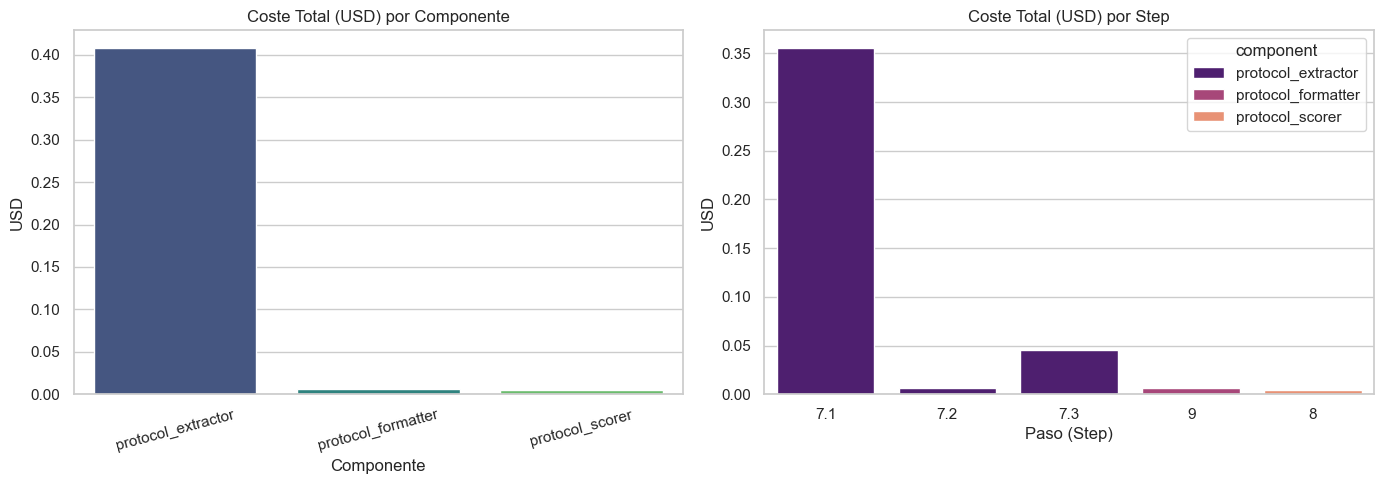

In [12]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Gráfico 1: Coste total por componente
plt.subplot(1, 2, 1)
sns.barplot(
    data=component_summary, x="component", y="total_cost_usd", palette="viridis"
)
plt.title("Coste Total (USD) por Componente")
plt.ylabel("USD")
plt.xlabel("Componente")
plt.xticks(rotation=15)

# Gráfico 2: Coste total por Paso (Step)
plt.subplot(1, 2, 2)
sns.barplot(
    data=step_summary, x="step", y="total_cost_usd", hue="component", palette="magma"
)
plt.title("Coste Total (USD) por Step")
plt.ylabel("USD")
plt.xlabel("Paso (Step)")

plt.tight_layout()
plt.show()

C:\Users\rebec\AppData\Local\Temp\ipykernel_34440\3933086939.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=step_summary_plot, x="step", y="total_cost_usd", ax=axes[0, 0], palette="Blues_r")
C:\Users\rebec\AppData\Local\Temp\ipykernel_34440\3933086939.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_calls, x="step", y="total_cost_usd", ax=axes[1, 1], palette="Set2")


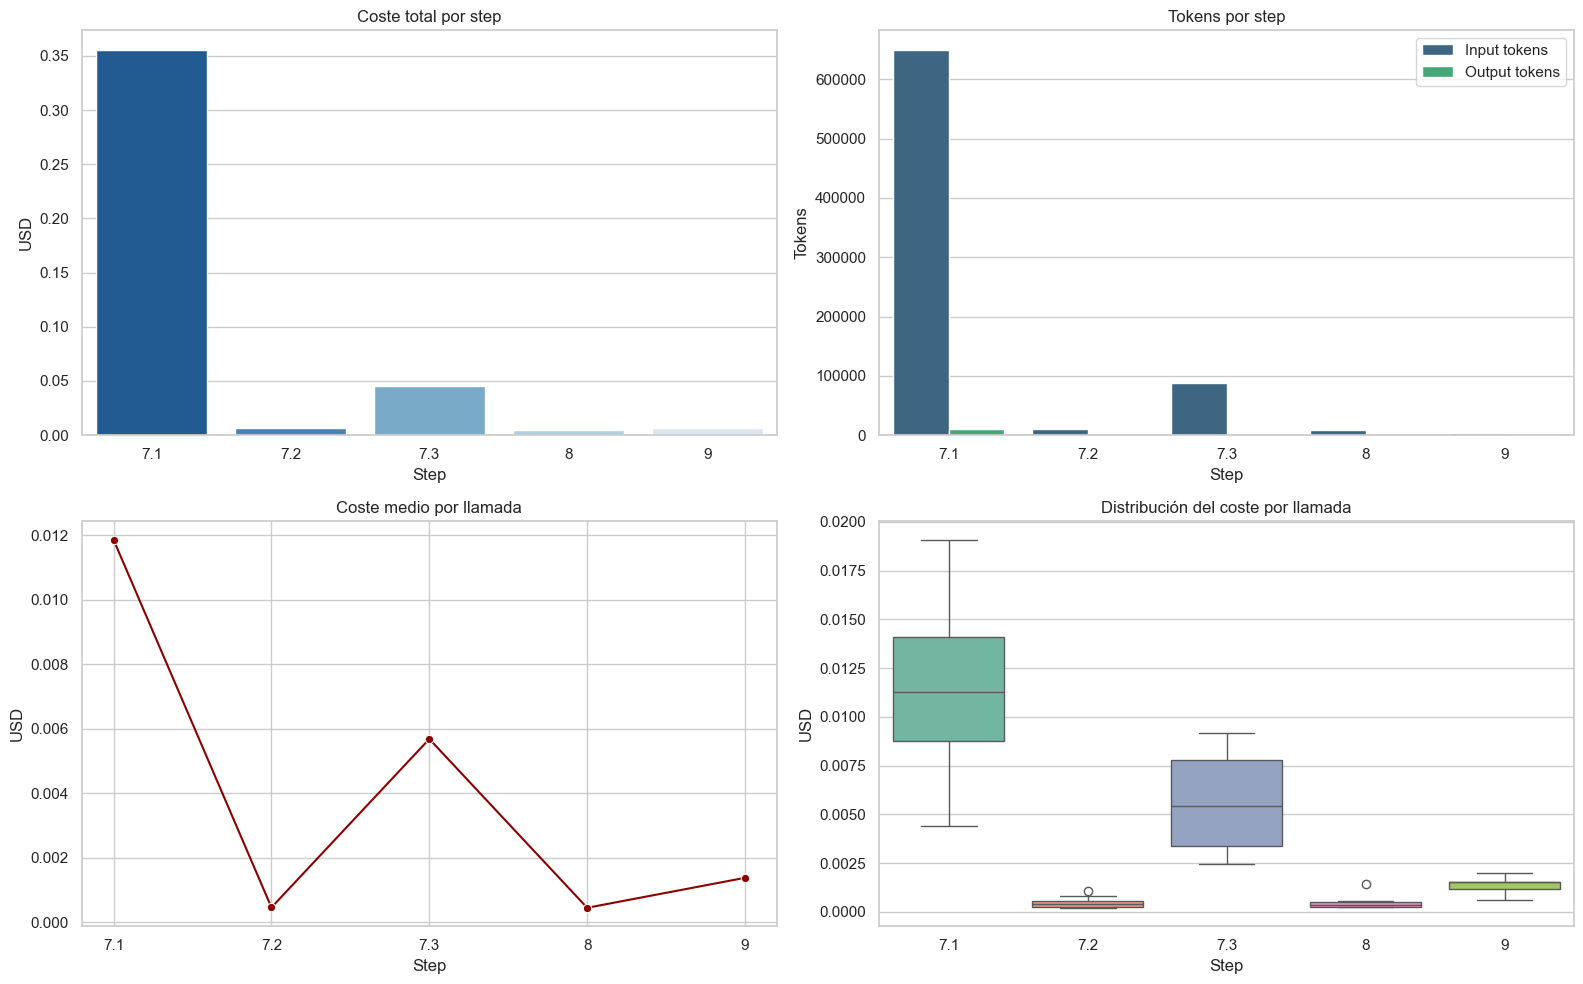

In [25]:
# Ordenamos los pasos para que los gráficos tengan una secuencia lógica
step_summary_plot = step_summary.copy()
step_summary_plot["step_num"] = pd.to_numeric(
    step_summary_plot["step"], errors="coerce"
)
step_summary_plot = step_summary_plot.sort_values("step_num")

# Preparación de datos para gráficos adicionales
tokens_step = (
    df_calls.groupby("step")
    .agg(
        total_input_tokens=("input_tokens", "sum"),
        total_output_tokens=("output_tokens", "sum"),
        total_tokens=("total_tokens", "sum"),
        total_cost_usd=("total_cost_usd", "sum"),
        avg_cost_per_call_usd=("total_cost_usd", "mean"),
    )
    .reset_index()
)
tokens_step["step_num"] = pd.to_numeric(tokens_step["step"], errors="coerce")
tokens_step = tokens_step.sort_values("step_num")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Coste total por step
sns.barplot(
    data=step_summary_plot,
    x="step",
    y="total_cost_usd",
    ax=axes[0, 0],
    palette="Blues_r",
)
axes[0, 0].set_title("Coste total por step")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("USD")

# 2) Tokens totales por step (input vs output)
tokens_melted = tokens_step.melt(
    id_vars="step",
    value_vars=["total_input_tokens", "total_output_tokens"],
    var_name="type",
    value_name="tokens",
)
tokens_melted["type"] = tokens_melted["type"].map(
    {"total_input_tokens": "Input tokens", "total_output_tokens": "Output tokens"}
)
sns.barplot(
    data=tokens_melted,
    x="step",
    y="tokens",
    hue="type",
    ax=axes[0, 1],
    palette="viridis",
)
axes[0, 1].set_title("Tokens por step")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Tokens")
axes[0, 1].legend(title="")

# 3) Coste medio por llamada por step
sns.lineplot(
    data=step_summary_plot,
    x="step",
    y="avg_cost_per_call_usd",
    marker="o",
    ax=axes[1, 0],
    color="darkred",
)
axes[1, 0].set_title("Coste medio por llamada")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("USD")

# 4) Distribución del coste por llamada en cada step
sns.boxplot(data=df_calls, x="step", y="total_cost_usd", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Distribución del coste por llamada")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("USD")

plt.tight_layout()
plt.show()